In [76]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from sklearn.metrics import confusion_matrix


In [77]:
DATA_PATH = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE"

IMAGE_PATH = os.path.join(DATA_PATH, "training/images")
GT_PATH    = os.path.join(DATA_PATH, "training/1st_manual")
FOV_PATH   = os.path.join(DATA_PATH, "training/mask")

image_files = sorted(os.listdir(IMAGE_PATH))
gt_files    = sorted(os.listdir(GT_PATH))
fov_files   = sorted(os.listdir(FOV_PATH))

print("Total Images:", len(image_files))

Total Images: 20


In [78]:
def preprocess(path):

    img = cv2.imread(path)
    green = img[:, :, 1]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)

    enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)

    return enhanced

In [79]:
def extract_thin(mask):

    mask = mask // 255

    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(mask, kernel, iterations=1)

    thin = mask - eroded
    thin[thin < 0] = 0

    return thin

In [80]:
def clean_binary(binary, min_area):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, 8)

    cleaned = np.zeros_like(binary)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 1

    return cleaned

In [81]:
def niblack_threshold(image):

    # Slight parameter tuning
    thresh = threshold_niblack(image, window_size=33, k=-0.09)

    binary = (image < thresh).astype(np.uint8)

    binary = clean_binary(binary, 90)

    return binary


def sauvola_threshold(image):

    # Slight parameter tuning
    thresh = threshold_sauvola(image, window_size=41, k=0.12)

    binary = (image < thresh).astype(np.uint8)

    binary = clean_binary(binary, 70)

    # Light dilation to preserve thin vessels
    kernel = np.ones((2,2), np.uint8)
    binary = cv2.dilate(binary, kernel, iterations=1)

    return binary

In [82]:
def compute_metrics(gt, pred, fov):

    valid = (fov > 0)

    gt   = gt[valid]
    pred = pred[valid]

    tp = np.sum((gt==1) & (pred==1))
    tn = np.sum((gt==0) & (pred==0))
    fp = np.sum((gt==0) & (pred==1))
    fn = np.sum((gt==1) & (pred==0))

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    dice        = (2*tp) / (2*tp + fp + fn + 1e-8)

    return sensitivity, specificity, accuracy, dice

In [83]:
niblack_results = []
sauvola_results = []

for i in range(len(image_files)):

    img = preprocess(os.path.join(IMAGE_PATH, image_files[i]))
    gt  = cv2.imread(os.path.join(GT_PATH, gt_files[i]), 0)
    fov = cv2.imread(os.path.join(FOV_PATH, fov_files[i]), 0)

    thin_gt = extract_thin(gt)

    n_pred = niblack_threshold(img)
    s_pred = sauvola_threshold(img)

    niblack_results.append(compute_metrics(thin_gt, n_pred, fov))
    sauvola_results.append(compute_metrics(thin_gt, s_pred, fov))

niblack_results = np.array(niblack_results)
sauvola_results = np.array(sauvola_results)

In [84]:
print("\n FINAL AVERAGE METRICS ")

print("\nNIBLACK")
print("Sensitivity:", np.mean(niblack_results[:,0]))
print("Specificity:", np.mean(niblack_results[:,1]))
print("Accuracy:",    np.mean(niblack_results[:,2]))
print("Dice:",        np.mean(niblack_results[:,3]))

print("\nSAUVOLA")
print("Sensitivity:", np.mean(sauvola_results[:,0]))
print("Specificity:", np.mean(sauvola_results[:,1]))
print("Accuracy:",    np.mean(sauvola_results[:,2]))
print("Dice:",        np.mean(sauvola_results[:,3]))


 FINAL AVERAGE METRICS 

NIBLACK
Sensitivity: 0.85161884287981
Specificity: 0.6150115564700207
Accuracy: 0.633783831953895
Dice: 0.2728690841669793

SAUVOLA
Sensitivity: 0.5863629284085683
Specificity: 0.8768034461662856
Accuracy: 0.8531761443390093
Dice: 0.39307688661827345


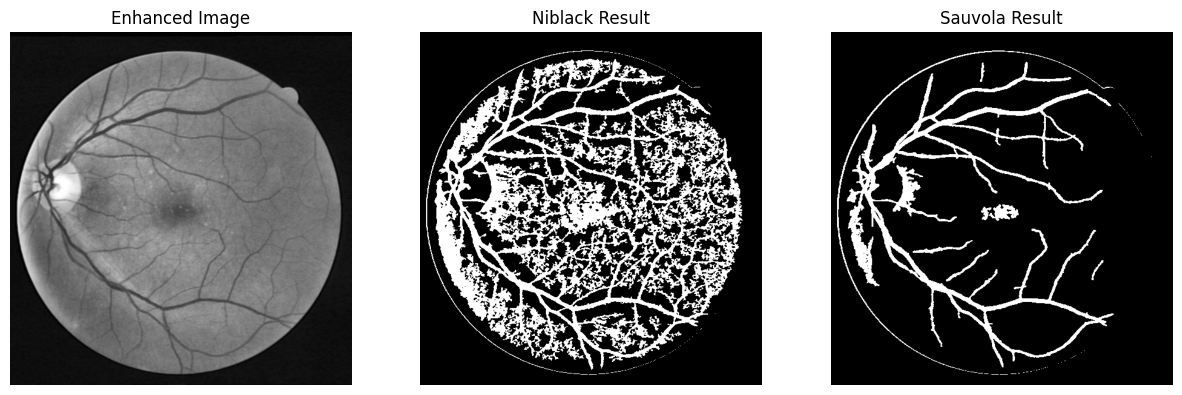

In [85]:
index = 0

img = preprocess(os.path.join(IMAGE_PATH, image_files[index]))
fov = cv2.imread(os.path.join(FOV_PATH, fov_files[index]), 0)
fov_mask = (fov > 0).astype(np.uint8)

n_pred = niblack_threshold(img) * fov_mask
s_pred = sauvola_threshold(img) * fov_mask

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Enhanced Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Niblack Result")
plt.imshow(n_pred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Sauvola Result")
plt.imshow(s_pred, cmap='gray')
plt.axis("off")

plt.show()